In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

import joblib

In [2]:
df = pd.read_csv("titanic.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [3]:
print(df.shape)

(418, 12)


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    object 
 4   Sex          418 non-null    object 
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    object 
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     object 
 11  Embarked     418 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 39.3+ KB


In [5]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,86
SibSp,0
Parch,0
Ticket,0
Fare,1


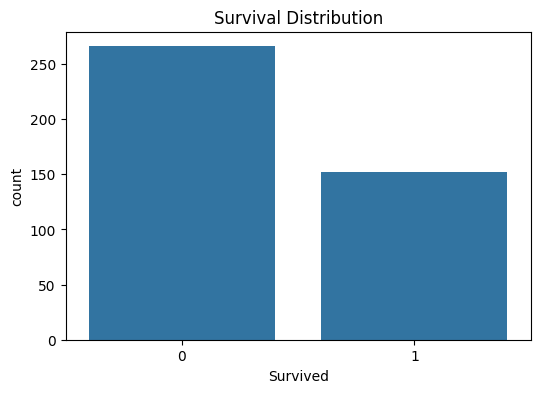

In [6]:
plt.figure(figsize=(6,4))

sns.countplot(x='Survived', data=df)

plt.title("Survival Distribution")

plt.show()

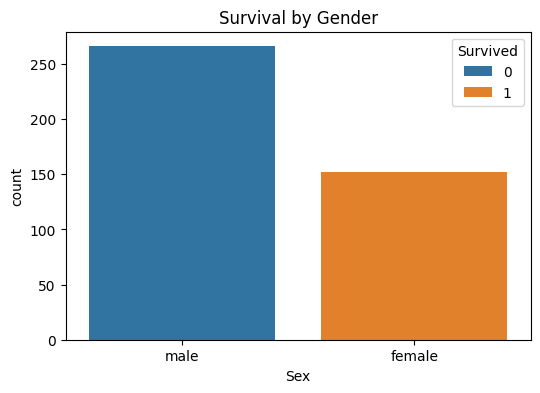

In [7]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='Sex',
    hue='Survived',
    data=df
)

plt.title("Survival by Gender")

plt.show()

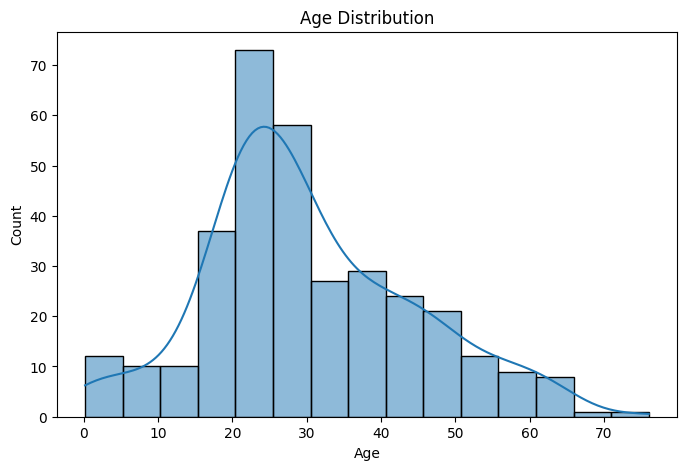

In [8]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['Age'],
    kde=True
)

plt.title("Age Distribution")

plt.show()

In [9]:
df['Age'].fillna(
    df['Age'].median(),
    inplace=True
)

df['Fare'].fillna(
    df['Fare'].median(),
    inplace=True
)

/tmp/ipykernel_2365/2492822503.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(
/tmp/ipykernel_2365/2492822503.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, 

In [10]:
df['Cabin_Present'] = df['Cabin'].notnull().astype(int)

In [12]:
df['Family_Size'] = (
    df['SibSp']
    + df['Parch']
    + 1
)

In [13]:
df['Title'] = df['Name'].str.extract(
    ' ([A-Za-z]+)\.',
    expand=False
)

<>:2: SyntaxWarning: invalid escape sequence '\.'
<>:2: SyntaxWarning: invalid escape sequence '\.'
/tmp/ipykernel_2365/1827547517.py:2: SyntaxWarning: invalid escape sequence '\.'
  ' ([A-Za-z]+)\.',


In [14]:
df['Title'].value_counts()

,count
Title,
Mr,240
Miss,78
Mrs,72
Master,21
Col,2
Rev,2
Ms,1
Dr,1
Dona,1


In [15]:
df['Title'] = df['Title'].replace(
    ['Dona','Rev','Dr','Major',
     'Col','Capt','Jonkheer'],
    'Rare'
)

In [16]:
df.drop(
    ['PassengerId',
     'Name',
     'Ticket',
     'Cabin'],
    axis=1,
    inplace=True
)


In [18]:
categorical_cols = [
    'Sex',
    'Embarked',
    'Title'
]

encoder = LabelEncoder()

for col in categorical_cols:
    df[col] = encoder.fit_transform(df[col])

In [19]:
X = df.drop(
    'Survived',
    axis=1
)

y = df['Survived']

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [21]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [22]:
lr = LogisticRegression()

lr.fit(
    X_train,
    y_train
)

lr_pred = lr.predict(X_test)

lr_acc = accuracy_score(
    y_test,
    lr_pred
)

print("Accuracy:", lr_acc)

Accuracy: 1.0


In [23]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

rf_pred = rf.predict(X_test)

rf_acc = accuracy_score(
    y_test,
    rf_pred
)

print("Accuracy:", rf_acc)

Accuracy: 1.0


In [24]:
results = pd.DataFrame({
    'Model':[
        'Logistic Regression',
        'Random Forest'
    ],
    'Accuracy':[
        lr_acc,
        rf_acc
    ]
})

results

,Model,Accuracy
0,Logistic Regression,1.0
1,Random Forest,1.0


In [26]:
results.sort_values(
    by='Accuracy',
    ascending=False
)

,Model,Accuracy
0,Logistic Regression,1.0
1,Random Forest,1.0


In [27]:
cm = confusion_matrix(
    y_test,
    rf_pred
)

cm

array([[50,  0],
       [ 0, 34]])

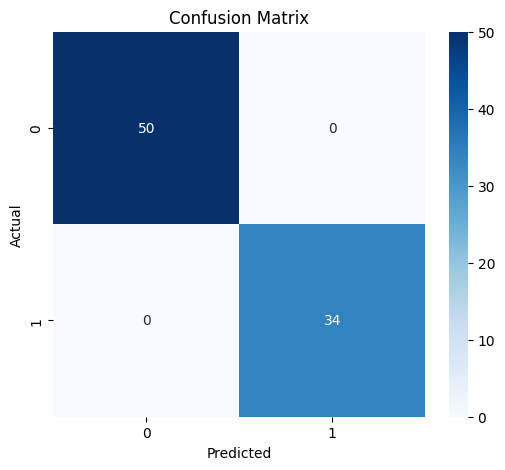

In [28]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [29]:
print(
    classification_report(
        y_test,
        rf_pred
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        50
           1       1.00      1.00      1.00        34

    accuracy                           1.00        84
   macro avg       1.00      1.00      1.00        84
weighted avg       1.00      1.00      1.00        84



In [31]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance

,Feature,Importance
1,Sex,0.660341
9,Title,0.255477
5,Fare,0.027445
2,Age,0.020271
8,Family_Size,0.011867
4,Parch,0.009375
0,Pclass,0.004321
3,SibSp,0.004064
6,Embarked,0.003601
7,Cabin_Present,0.003237


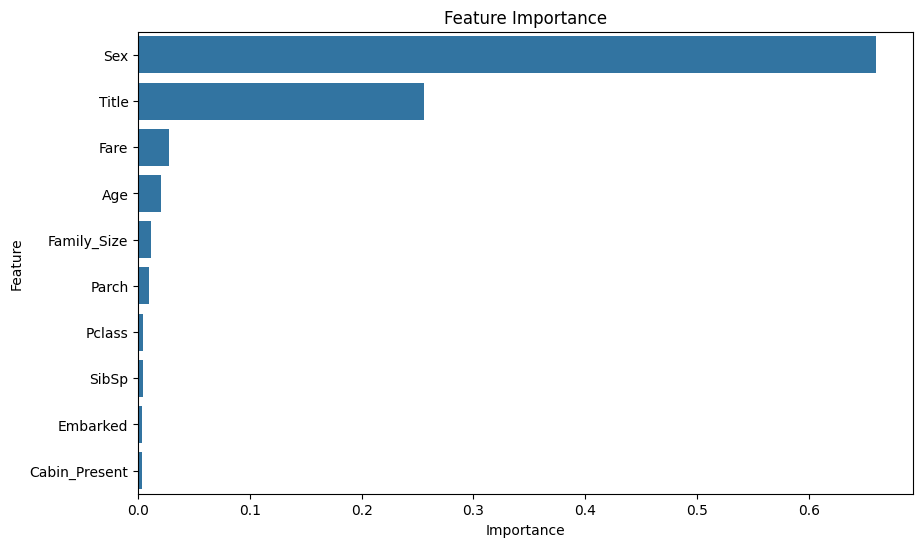

In [32]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance,
    x='Importance',
    y='Feature'
)

plt.title("Feature Importance")

plt.show()

In [33]:
joblib.dump(
    rf,
    'titanic_model.pkl'
)

print("Model Saved")

Model Saved


In [34]:
model = joblib.load(
    'titanic_model.pkl'
)

sample = X.iloc[[0]]

sample_scaled = scaler.transform(sample)

prediction = model.predict(
    sample_scaled
)

print("Prediction:", prediction[0])

if prediction[0] == 1:
    print("Passenger Survived")
else:
    print("Passenger Did Not Survive")

Prediction: 0
Passenger Did Not Survive
